# Correcting plate position: hit-calling vs profiling

Position effects -- edge evaporation, thermal corners, dispensing drift -- are real, but correcting them is not
free. Whether you *should* correct turns on one question: **are you measuring one readout, or a whole profile?**

`mt.pp.correct_plate_position` removes a plate's row and column effects with a two-way median polish (it
iteratively subtracts row and column medians, so a few extreme wells cannot define the gradient). Its default,
`method="b_score"` ({cite:t}`Brideau_2003`), then divides the residual by the plate's median absolute deviation
(MAD) to give a robust, position-corrected z-score per plate; `method="median_polish"` subtracts the effects
while keeping the data's units. This page shows both faces: the rescue on a controlled synthetic plate, and the
cost on real JUMP profiles. The rule to carry away: **position correction -- either method -- is built for
hit-calling against a gradient, not for multivariate profiling; the B-score is just the sharpest version of the
mistake when you misapply it.**

In [1]:
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mantispy as mt
from mantispy._core.plate import PLATE_FORMATS, well_col, well_name, well_row
from mantispy._core.schema import stamp

warnings.filterwarnings("ignore")

## When it rescues: one readout, calling hits

On a single readout, a smooth gradient buries real hits: an active well in the cold corner can read lower than an
inactive one in the hot corner. Below is a synthetic plate with a strong row/column gradient and six real hits
scattered at random -- a randomized layout, as the method assumes. We measure whether correction helped the only
way that matters here: does the ranking recover the hits, as precision among the top six wells?

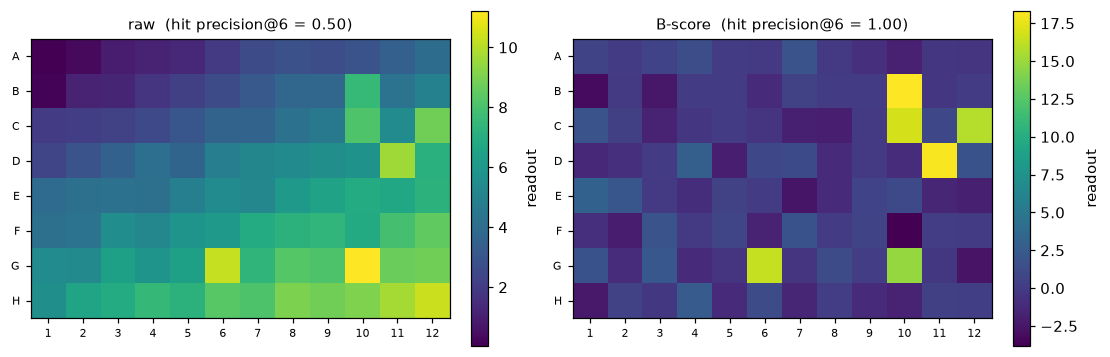

In [2]:
n_rows, n_cols = PLATE_FORMATS[96]
names = [well_name(r, c) for r in range(n_rows) for c in range(n_cols)]
rows = np.array([well_row(w) for w in names], dtype=float)
cols = np.array([well_col(w) for w in names], dtype=float)
rng = np.random.default_rng(0)

gradient = 6.0 * rows / rows.max() + 4.0 * cols / cols.max()
readout = gradient + rng.normal(0.0, 0.3, len(names))
hits = rng.choice(len(names), size=6, replace=False)  # six real hits, scattered at random
readout[hits] += 3.0  # a randomized layout, as B-score assumes

plate = ad.AnnData(
    X=readout.reshape(-1, 1).astype(np.float32),
    obs=pd.DataFrame(
        {"Metadata_Plate": "demo", "Metadata_Well": names, "Metadata_Control": True},
        index=[str(i) for i in range(len(names))],
    ),
    var=pd.DataFrame(index=["readout"]),
)
stamp(plate, resolution="well")
scored = mt.pp.correct_plate_position(plate, method="b_score", copy=True)


def hit_precision(values, k=6):
    """Share of the true hits among the top-k wells -- how we measure whether correction helped."""
    return len(set(np.argsort(values)[::-1][:k]) & set(hits.tolist())) / k


raw_precision = hit_precision(readout)
b_precision = hit_precision(np.asarray(scored.X, dtype=float)[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
mt.pl.plate(plate, color="readout", plate="demo", ax=axes[0])
axes[0].set_title(f"raw  (hit precision@6 = {raw_precision:.2f})", fontsize=10)
mt.pl.plate(scored, color="readout", plate="demo", ax=axes[1])
axes[1].set_title(f"B-score  (hit precision@6 = {b_precision:.2f})", fontsize=10)
plt.show()

Raw, the gradient lifts hot-corner background above the hits sitting in cold wells, so several true hits miss the
top six; after the B-score the gradient is gone and the hits rise to the top (see the precision in the panel
titles). This is the B-score's home: a **single readout**, **hit-calling**, a **randomized layout**, and
**mostly-inactive wells** -- all four conditions matter, and dropping any one changes the calculus below.

## When it removes signal: a whole profile

A morphological profile is a different problem: hundreds of correlated features, where position is a minor
component and the biology lives in each compound's full multivariate shift -- which has to stay comparable across
plates and laboratories. Here are five plates from one laboratory that carry a real, strong position artifact,
beside five clean plates from other labs, each normalized per plate against its negative controls (`negcon`, the
DMSO wells). `detect_plate_position` scores each plate by the cross-validated R-squared of the row/column fit on
held-out control wells -- above zero means the structure generalizes:

In [3]:
flagged = ["BR00126113", "BR00126114", "BR00126115", "BR00126116", "BR00126117"]
clean = ["JCPQC051", "ACPJUM012", "1053600674", "GR00003394", "CP1-SC1-25"]
jump = mt.ds.jump_target2(plates=flagged + clean)
mt.pp.normalize(jump, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(jump, na_cutoff=0.0)
jump = mt.pp.subset_features(jump)

mt.pp.detect_plate_position(jump, reference="negcon")
detection = jump.uns["mantispy"]["plate_position_detection"].copy()
source = jump.obs.drop_duplicates("Metadata_Plate").set_index(
    jump.obs.drop_duplicates("Metadata_Plate")["Metadata_Plate"].astype(str)
)["Metadata_Source"]
detection["source"] = detection["plate"].map(source.to_dict())
detection.sort_values("cv_r2_median", ascending=False).round({"cv_r2_median": 3, "frac_features_positive": 3})

,plate,n_controls,cv_r2_median,frac_features_positive,reason,source
2,BR00126113,64,0.784,0.823,,source_4
5,BR00126116,64,0.754,0.789,,source_4
4,BR00126115,64,0.712,0.795,,source_4
6,BR00126117,64,0.710,0.793,,source_4
3,BR00126114,64,0.504,0.651,,source_4
8,GR00003394,256,-0.129,0.307,,source_9
7,CP1-SC1-25,64,-0.545,0.153,,source_7
9,JCPQC051,64,-0.659,0.169,,source_3
1,ACPJUM012,64,-0.825,0.026,,source_5
0,1053600674,65,-0.839,0.084,,source_2


The artifact is real and lab-specific: the five source_4 plates generalize strongly (`cv_r2_median` well above
zero, most features affected); the others score below zero. Two cautions. A positive score means the position
structure is *real and stable on the controls* -- it does **not** promise that correcting it helps the biology.
And a plate that generalizes this strongly is a **quality-control flag in its own right**: on a profiling screen
it is often better to exclude or inspect it than to correct it. (In our scan of the full Target-2 set, not shown
here, only six of its 141 plates scored positive, five of them this one lab -- position artifacts are rare and
localized, so blanket correction spends signal everywhere to fix a few.)

We flagged those plates for exclusion; before settling for that, measure whether correcting them would help
instead. Cross-source compound retrieval -- can the same compound, run at different laboratories, be found again
-- before and after correcting only the flagged plates (through `plates=`), as mean average precision (mAP)
against a corrected null (a permutation test; we count how many compounds clear it):

In [4]:
def cross_source_map(adata):
    """Mean cross-source compound mAP, and how many compounds clear the corrected null."""
    treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
    mt.tl.map(
        treated,
        pos_sameby=["Metadata_Perturbation"],
        pos_diffby=["Metadata_Source"],
        neg_diffby=["Metadata_Perturbation"],
        null_size=500,
        seed=0,
    )
    scores = treated.uns["mantispy"]["map"]
    return round(float(scores["mean_average_precision"].mean()), 3), int(scores["below_corrected_p"].sum())


passing = list(detection.loc[detection["cv_r2_median"] > 0, "plate"])
n_treated = int(jump.obs.loc[~jump.obs["Metadata_Control"].to_numpy(), "Metadata_Perturbation"].nunique())

ladder = {"normalize only": cross_source_map(jump)}
for method in ("median_polish", "b_score"):
    corrected = jump.copy()
    mt.pp.correct_plate_position(corrected, method=method, reference="negcon", plates=passing)
    ladder[f"+ {method} (only the flagged plates)"] = cross_source_map(corrected)

pd.DataFrame(
    [
        {"pipeline": name, "cross-source mAP": value, f"significant of {n_treated}": hits}
        for name, (value, hits) in ladder.items()
    ]
)

,pipeline,cross-source mAP,significant of 301
0,normalize only,0.016,38
1,+ median_polish (only the flagged plates),0.015,25
2,+ b_score (only the flagged plates),0.014,21


Correcting does not help -- it hurts. The mAP changes are small (0.016 to 0.014 at this single seed), so the
clearer evidence is the count of compounds clearing the null, which falls from 38 to 21 as correction is added.
The function did exactly what it promises -- it removed the row and column structure -- but two things make that
a bad trade on a profile. The fit is estimated from only a few dozen control wells, so subtracting it injects
noise into every treated well; and the B-score then rescales each plate by its MAD on top of the per-plate
normalization already applied, so the same compound is transformed differently on each plate -- exactly what
cross-source retrieval needs to stay consistent. For profiling the right move is per-plate normalization plus
`pp.harmony` on the batch (which aligns the laboratories in an embedding), with `detect_plate_position` to flag
the rare plate worth excluding -- not a blanket position correction.

## Which to use

| If you are... | use |
| --- | --- |
| calling hits from a single readout, randomized layout | `correct_plate_position(method="b_score")` |
| removing a known gradient but keeping your units | `correct_plate_position(method="median_polish")` |
| building multivariate profiles | **don't position-correct** -- normalize + `pp.harmony` on the batch. Calling it here with the default `b_score` also double-normalizes, the worst case. |
| facing a plate scoring `cv_r2_median > 0` on a profiling screen | treat it as QC: exclude or inspect it. Correcting even that one plate still cost retrieval here. |

The recommended path for a profiling pipeline:

```python
import scanpy as sc

mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.detect_plate_position(adata, reference="negcon")
flagged = adata.uns["mantispy"]["plate_position_detection"].query("cv_r2_median > 0")["plate"]
adata = adata[~adata.obs["Metadata_Plate"].isin(flagged)].copy()   # drop plates with a position artifact
sc.pp.pca(adata, n_comps=50)
mt.pp.harmony(adata, batch_key="Metadata_Batch")                   # align the laboratories
```

Caveats behind the table:

- **Nonrandom layouts.** Both methods assume position is independent of treatment. Controls lining whole columns,
  or a dose gradient across columns, *is* the position signal -- correcting it destroys the design
  ({cite:t}`Brideau_2003`; and the median polish can only fit a column effect where control wells sit).
- **High-hit-rate plates.** Median polish and the MAD assume most wells are inactive; many hits contaminate the
  robust center and the B-score compresses real signal.
- **Don't double-normalize.** The B-score already rescales per plate; run it *instead of* a per-plate
  normalization, or use `method="median_polish"` to keep your own.
- **A learned, different regime.** For genetic perturbations with deep features, learned well-position
  correctors (e.g. cpDistiller) help where this linear correction does not -- a different problem from the
  linear, CellProfiler-feature profiling here.

One readout, calling hits against a gradient: correct. A whole profile: don't -- the B-score buys clean plates by
spending the signal you came for. The within-plate mechanics are in
{doc}`the artifacts tutorial </tutorials/profiles/artifacts>`.